# Importando as bibliotecas

In [133]:
# Importando as bibliotecas que serão usadas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8,5)

# Importando o dataset

In [134]:
df = pd.read_csv("/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv") # Define o dataframe

df.tail() # Mostra as útimas 5 linhas do dataframe

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


# Análise Exploratória de Dados (EDA)

In [135]:
df.info() # Informações estruturais do dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [136]:
df.describe() # Exibe informações descritivas das colunas numéricas

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [137]:
df.isna().sum() # Verifica se há valores nulos

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [138]:
df.duplicated().sum() # Verifica se há registros duplicados

np.int64(0)

In [139]:
df.shape # Mostra a quantidade de linhas e colunas 

(569, 33)

In [140]:
df["diagnosis"].value_counts() # Verifica a distribuição dos tipos de tumores

diagnosis
B    357
M    212
Name: count, dtype: int64

In [141]:
# Deleta a coluna Id caso exista no dataset por não oferecer valor preditivo e a coluna Unnamed: 32 por conter somente valores nulos

if "id" in df.columns:
    df = df.drop(columns=["id"])

df = df.drop(columns=["Unnamed: 32"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


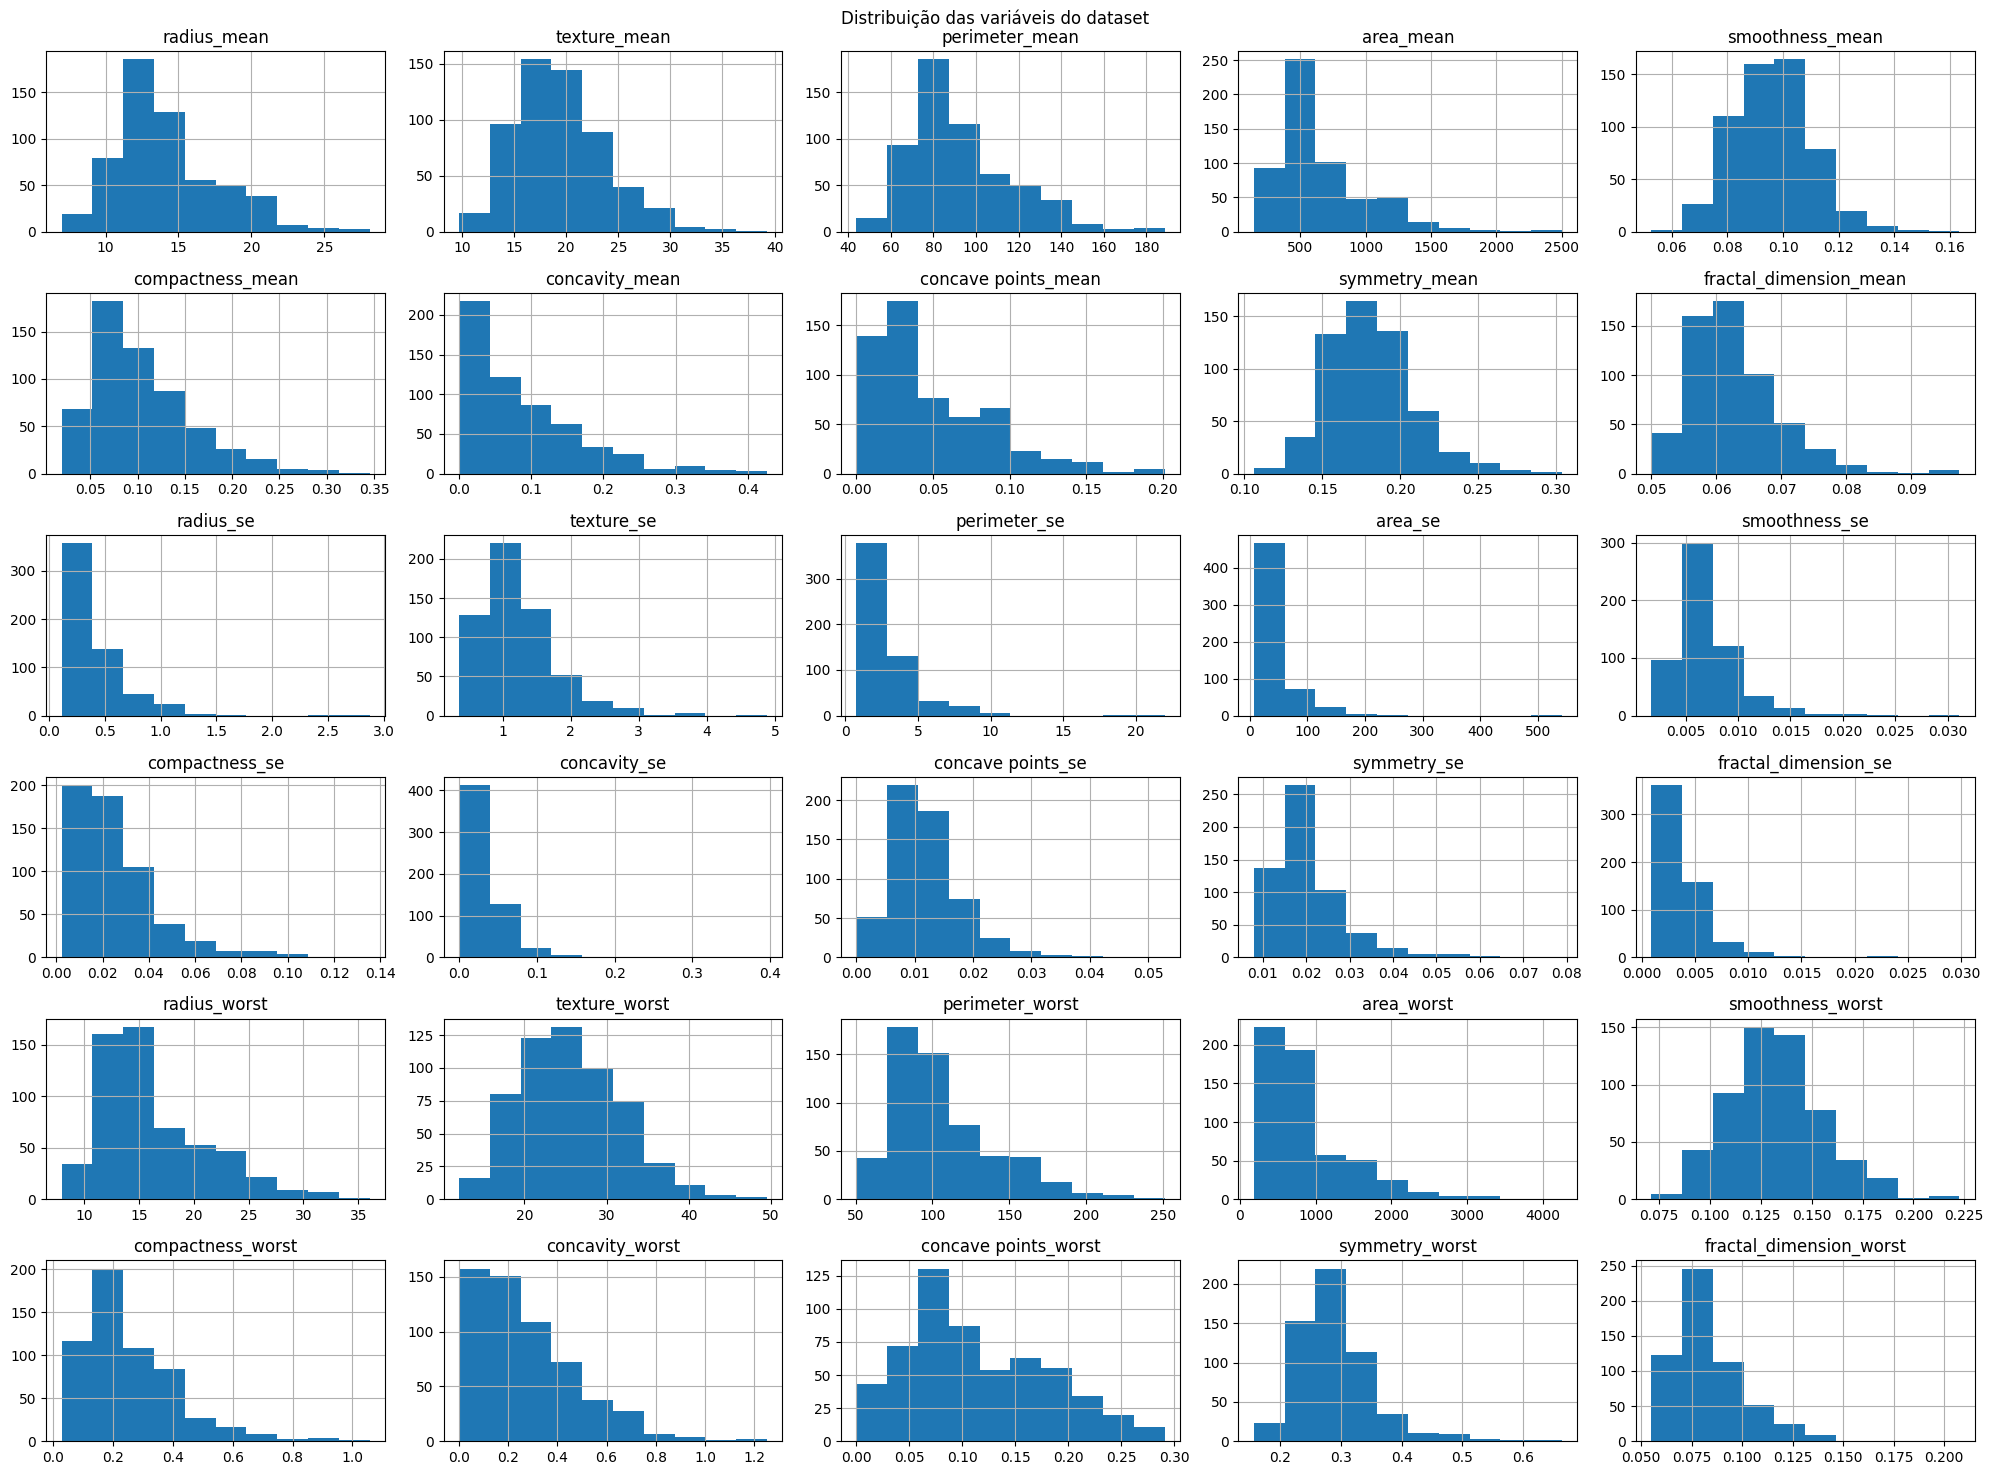

In [142]:
# Plota um histograma das características(features) do dataset
df.hist(figsize=(20,15))

plt.suptitle("Distribuição das variáveis do dataset")

plt.tight_layout()

plt.show()

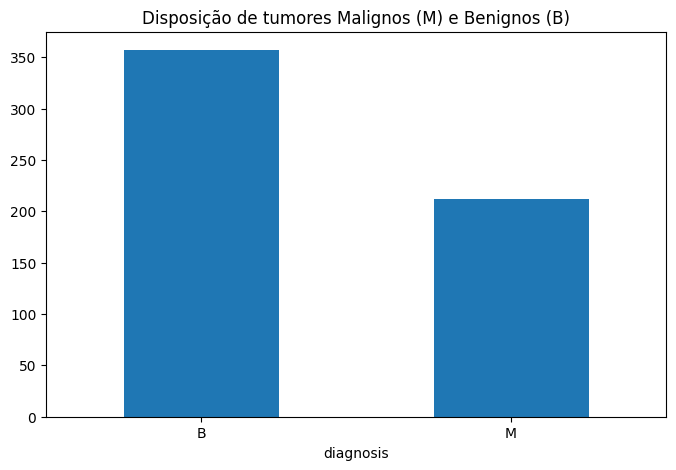

In [143]:
# Plota um gráfico de barras da distribuição do alvo(target)

df["diagnosis"].value_counts().plot(kind="bar")

plt.xticks(rotation=0)
plt.title("Disposição de tumores Malignos (M) e Benignos (B)")

plt.show()

# Divisão dos dados

In [144]:
x = df.drop(columns=["diagnosis"]) # Define x como as caracteristicas dos tumores
y = df["diagnosis"] # Define y como os tipos de tumores

In [145]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y) # Separa os dados de treino e teste

print(f"Dados de treinamento de x: {x_train.shape}\n")
print(f"Dados de teste de X: {x_test.shape}\n")
print(f"Dados de treino de Y: {y_train.value_counts()}\n")
print(f"Dados de teste de Y: {y_test.value_counts()}")

Dados de treinamento de x: (455, 30)

Dados de teste de X: (114, 30)

Dados de treino de Y: diagnosis
B    285
M    170
Name: count, dtype: int64

Dados de teste de Y: diagnosis
B    72
M    42
Name: count, dtype: int64


# Treinamento

In [146]:
# SVM Linear

# Define a padronização e o modelo
pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C = 1, random_state=42))
])

pipeline_linear.fit(x_train, y_train) # Treina o modelo com os dados de treinamento

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, kernel='linear', random_state=42))])

In [147]:
# SVM Não Linear

# Define a padronização e o modelo
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
])

pipeline_rbf.fit(x_train, y_train) # Treina o modelo com os dados de treinamento

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, random_state=42))])

# Teste e Avaliação

**SVM LINEAR**

In [148]:
y_pred_linear = pipeline_linear.predict(x_test) # Faz as previsões com os dados de teste

acc_score_linear = accuracy_score(y_pred_linear, y_test) # Compara as previsões com os dados de teste de y corretos e gera a acurácia

print(f"Acurácia do modelo linear: {acc_score_linear:.4f}")

Acurácia do modelo linear: 0.9649


In [149]:
print("Relatório de classificação - SMV Linear: ")

print(classification_report(y_test, y_pred_linear))

Relatório de classificação - SMV Linear: 
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



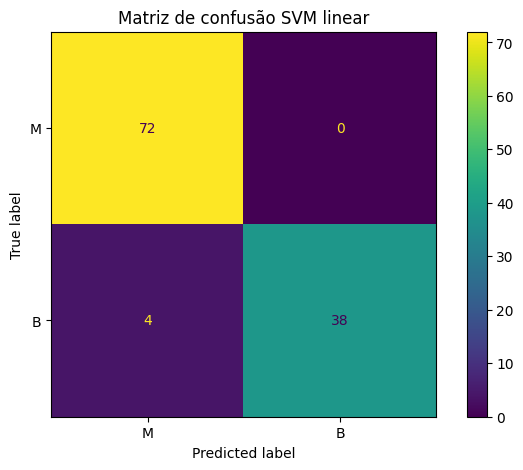

In [150]:
# Gera a matriz de confusão

cm_linear = confusion_matrix(y_test, y_pred_linear)

display = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=y.unique())

display.plot()
plt.title("Matriz de confusão SVM linear")
plt.show()

In [151]:
scores_linear = cross_val_score(pipeline_linear, x, y, cv=5) # Realiza a validação cruzada

print(f"Acurácia em cada fold: {scores_linear}\n")
print(f"Média: {scores_linear.mean():.4f}\n")
print(f"Desvio Padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]

Média: 0.9719

Desvio Padrão: 0.0086


**SVM NÃO LINEAR**

In [152]:
y_pred_rbf = pipeline_rbf.predict(x_test) # Faz as previsões com os dados de teste

acc_score_rbf = accuracy_score(y_pred_rbf, y_test) # Compara as previsões com os dados de teste de y corretos e gera a acurácia

print(f"Acurácia do modelo linear: {acc_score_rbf:.4f}")

Acurácia do modelo linear: 0.9737


In [153]:
print("Relatório de classificação - SMV Não-Linear: ")

print(classification_report(y_test, y_pred_rbf))

Relatório de classificação - SMV Não-Linear: 
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



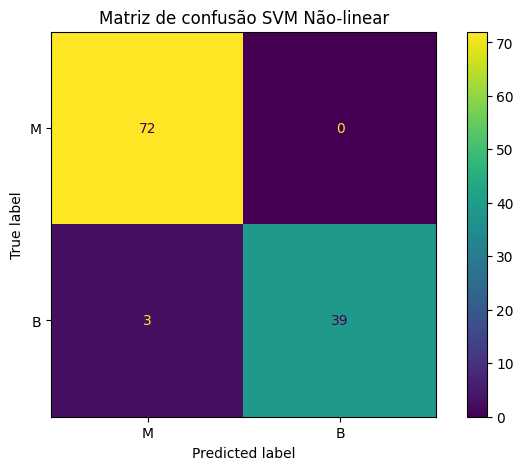

In [154]:
# Gera a matriz de confusão

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

display = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=y.unique())

display.plot()
plt.title("Matriz de confusão SVM Não-linear")
plt.show()

In [155]:
scores_rbf = cross_val_score(pipeline_linear, x, y, cv=5) # Realiza a validação cruzada

print(f"Acurácia em cada fold: {scores_rbf}\n")
print(f"Média: {scores_rbf.mean():.4f}\n")
print(f"Desvio Padrão: {scores_rbf.std():.4f}")

Acurácia em cada fold: [0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]

Média: 0.9719

Desvio Padrão: 0.0086


# Comparação dos modelos

In [156]:
comparacao = pd.DataFrame({
    "Modelo": ["Linear", "Não Linear"],
    "Acurácia": [acc_score_linear, acc_score_rbf],
    "Média": [scores_linear.mean(), scores_rbf.mean()],
    "Desvio-Padrão": [scores_linear.std(), scores_rbf.std()]
}) # Cria um dataframe com as comparações dos modelos

comparacao # Mostra o dataframe de comparação

,Modelo,Acurácia,Média,Desvio-Padrão
0,Linear,0.964912,0.971899,0.008557
1,Não Linear,0.973684,0.971899,0.008557
